<a href="https://www.kaggle.com/code/omborse771924/food-delivery-time-prediction-eda?scriptVersionId=341769073" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dharmendrapandit12/food-delivery-time-prediction-dataset/Food_Delivery_Time_Prediction.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/dharmendrapandit12/food-delivery-time-prediction-dataset/Food_Delivery_Time_Prediction.csv')

In [3]:
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [4]:
df.tail()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
49995,ORD049996,2025-03-08,14,Saturday,1,0,Fog,Industrial,Industrial,Electric Scooter,...,1,Medium,25,33.67,Long,Low,4,28.6,Normal,94
49996,ORD049997,2025-10-23,8,Thursday,0,0,Clear,Suburban,Residential,Bike,...,4,Medium,35,15.92,Long,Low,5,44.0,Normal,54
49997,ORD049998,2025-10-24,7,Friday,0,0,Storm,Residential,CBD,Scooter,...,1,Low,9,19.38,Long,Low,9,23.7,Normal,66
49998,ORD049999,2025-03-16,20,Sunday,1,0,Clear,Residential,CBD,Scooter,...,2,Medium,26,30.92,Long,Moderate,7,28.4,Priority,92
49999,ORD050000,2025-10-21,21,Tuesday,0,0,Rain,Residential,Residential,Bike,...,3,Low,24,35.51,Long,Moderate,8,29.5,Normal,103


In [5]:
df.info

<bound method DataFrame.info of         Order_ID  Order_Date  Order_Hour Day_of_Week  Is_Weekend  Is_Festival  \
0      ORD000001  2025-10-28           8     Tuesday           0            0   
1      ORD000002  2025-09-26          12      Friday           0            0   
2      ORD000003  2025-01-26          18      Sunday           1            0   
3      ORD000004  2025-11-19          12   Wednesday           0            0   
4      ORD000005  2025-08-04          18      Monday           0            0   
...          ...         ...         ...         ...         ...          ...   
49995  ORD049996  2025-03-08          14    Saturday           1            0   
49996  ORD049997  2025-10-23           8    Thursday           0            0   
49997  ORD049998  2025-10-24           7      Friday           0            0   
49998  ORD049999  2025-03-16          20      Sunday           1            0   
49999  ORD050000  2025-10-21          21     Tuesday           0            0

In [6]:
df.describe()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.847700,0.283600,0.049100,4.439744,3.951646,4.175368,2.652740,24.03118,26.201744,9.728920,31.759634,83.868980
std,5.525291,0.450749,0.216079,2.927752,0.294960,0.356201,1.590359,8.34877,12.620079,4.330849,9.510842,35.426899
min,0.000000,0.000000,0.000000,0.100000,3.200000,3.300000,1.000000,5.00000,0.080000,2.000000,8.000000,10.000000
25%,10.000000,0.000000,0.000000,2.200000,3.700000,3.900000,1.000000,18.00000,16.330000,6.000000,25.300000,58.000000
50%,14.000000,0.000000,0.000000,3.800000,3.900000,4.200000,2.000000,24.00000,25.620000,9.000000,33.100000,78.000000
75%,19.000000,1.000000,0.000000,5.900000,4.100000,4.400000,4.000000,30.00000,35.480000,14.000000,39.600000,102.000000
max,23.000000,1.000000,1.000000,15.000000,5.000000,5.000000,7.000000,51.00000,70.820000,18.000000,48.300000,180.000000


In [7]:
df.isnull

<bound method DataFrame.isnull of         Order_ID  Order_Date  Order_Hour Day_of_Week  Is_Weekend  Is_Festival  \
0      ORD000001  2025-10-28           8     Tuesday           0            0   
1      ORD000002  2025-09-26          12      Friday           0            0   
2      ORD000003  2025-01-26          18      Sunday           1            0   
3      ORD000004  2025-11-19          12   Wednesday           0            0   
4      ORD000005  2025-08-04          18      Monday           0            0   
...          ...         ...         ...         ...         ...          ...   
49995  ORD049996  2025-03-08          14    Saturday           1            0   
49996  ORD049997  2025-10-23           8    Thursday           0            0   
49997  ORD049998  2025-10-24           7      Friday           0            0   
49998  ORD049999  2025-03-16          20      Sunday           1            0   
49999  ORD050000  2025-10-21          21     Tuesday           0           

In [8]:
df.isnull().sum(

)

Order_ID                      0
Order_Date                    0
Order_Hour                    0
Day_of_Week                   0
Is_Weekend                    0
Is_Festival                   0
Weather                       0
Pickup_Zone                   0
Dropoff_Zone                  0
Vehicle_Type                  0
Rider_Experience_Years        0
Rider_Rating                  0
Restaurant_Rating             0
Cuisine_Type                  0
Order_Items                   0
Restaurant_Load               0
Preparation_Time_Min          0
Road_Distance_km              0
Delivery_Distance_Category    0
Traffic_Level                 0
Number_of_Signals             0
Average_Speed_kmph            0
Delivery_Priority             0
Time_taken_min                0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='object')

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order_ID                    50000 non-null  object        
 1   Order_Date                  50000 non-null  datetime64[ns]
 2   Order_Hour                  50000 non-null  int64         
 3   Day_of_Week                 50000 non-null  object        
 4   Is_Weekend                  50000 non-null  int64         
 5   Is_Festival                 50000 non-null  int64         
 6   Weather                     50000 non-null  object        
 7   Pickup_Zone                 50000 non-null  object        
 8   Dropoff_Zone                50000 non-null  object        
 9   Vehicle_Type                50000 non-null  object        
 10  Rider_Experience_Years      50000 non-null  float64       
 11  Rider_Rating                50000 non-null  float64   

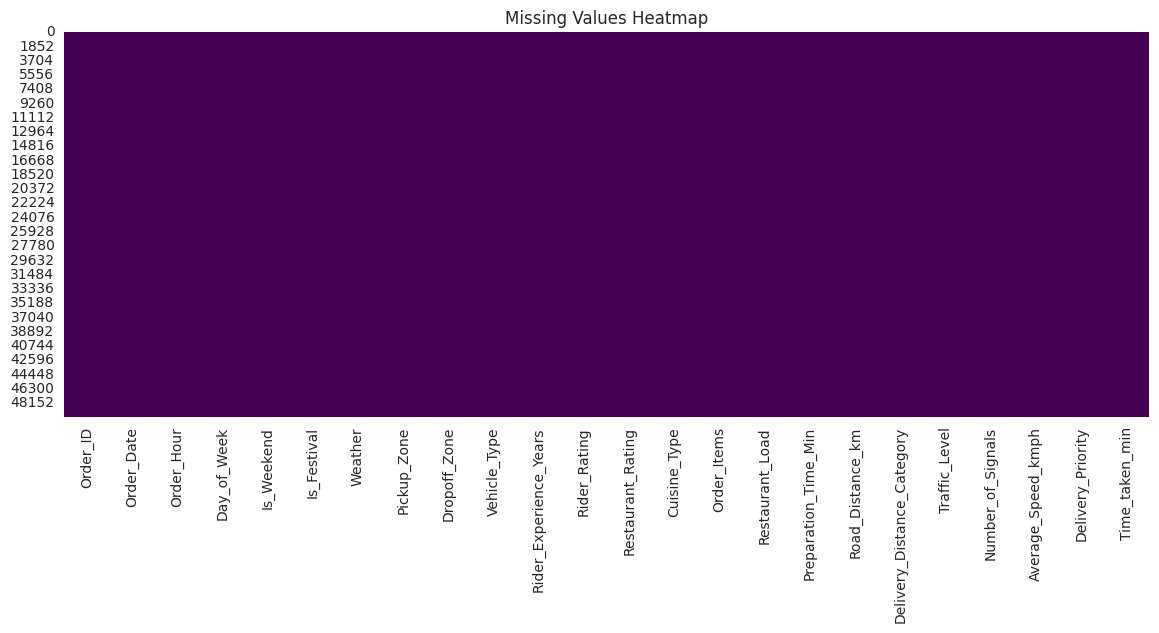

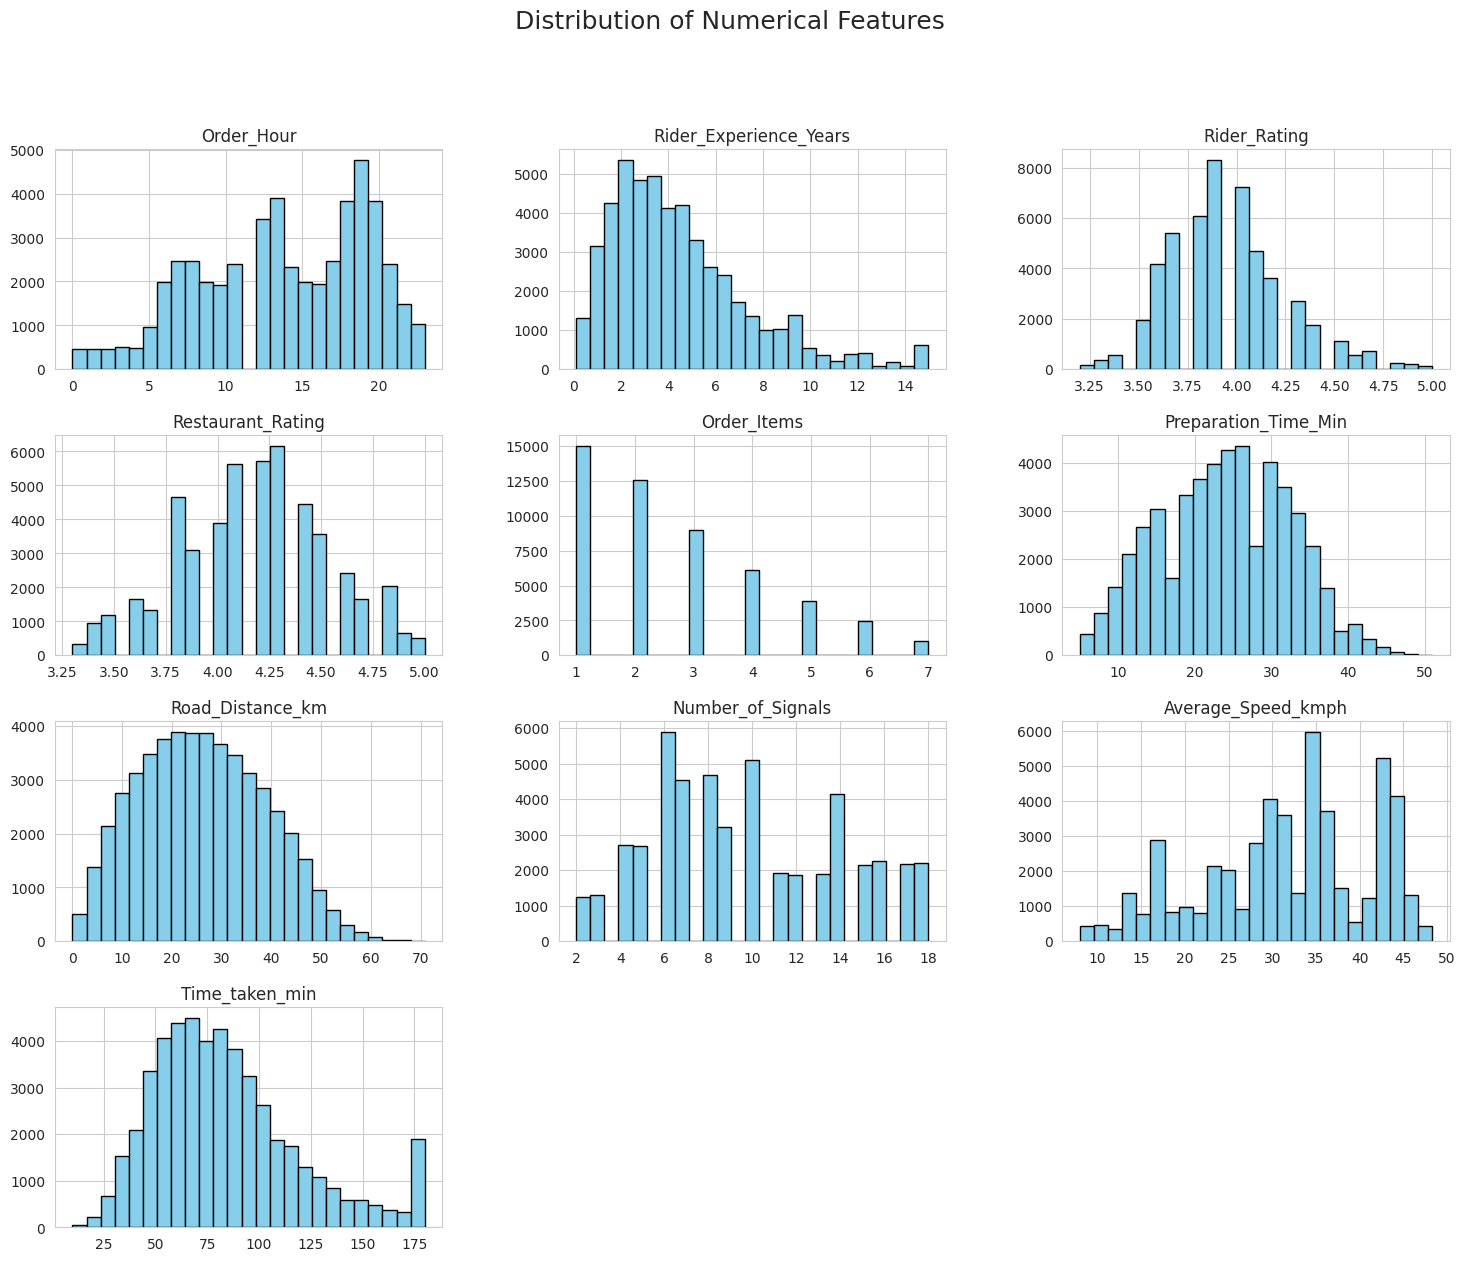

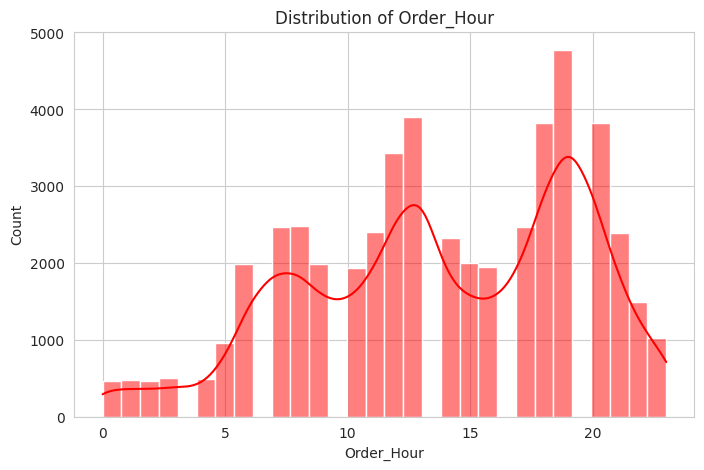

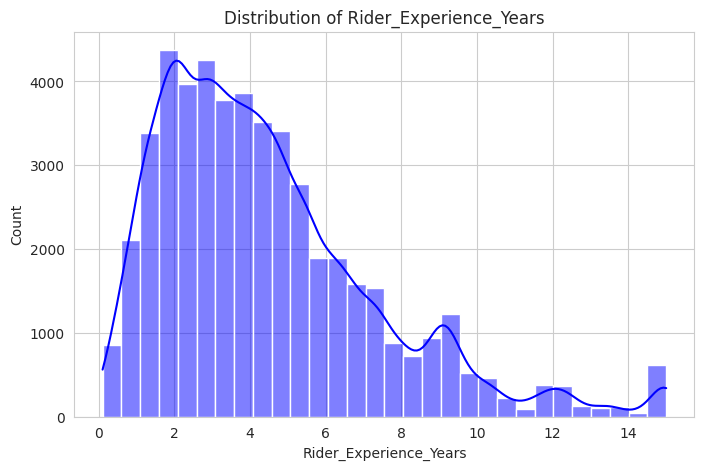

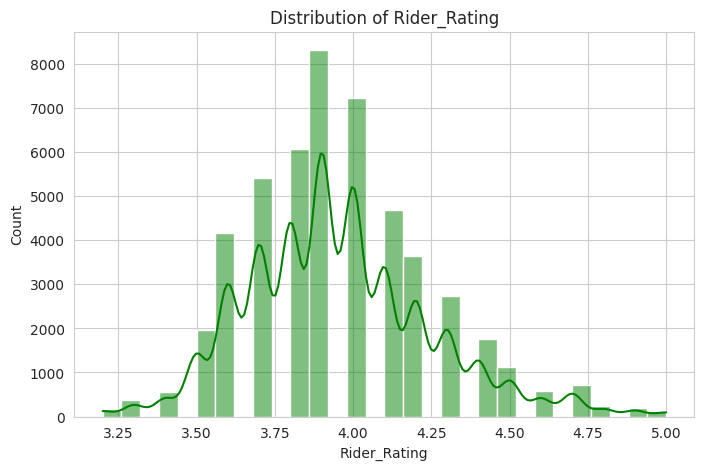

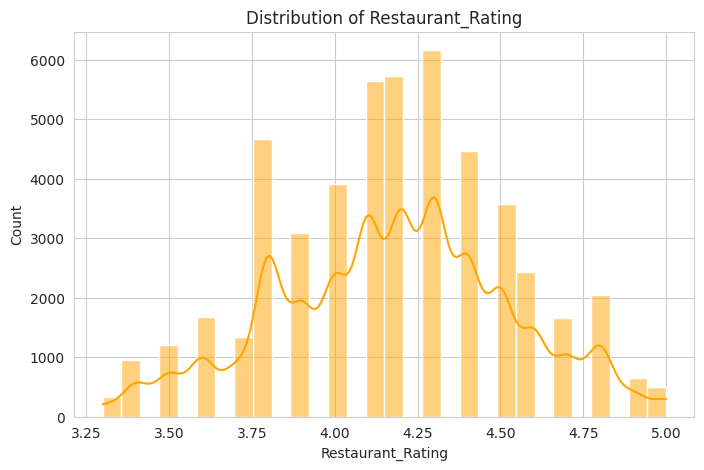

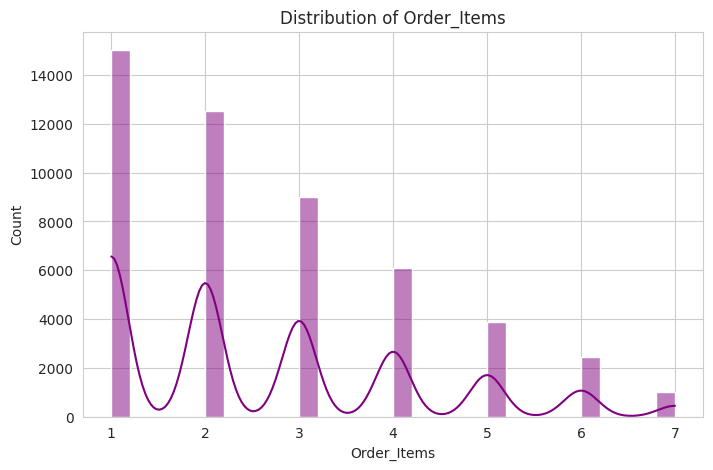

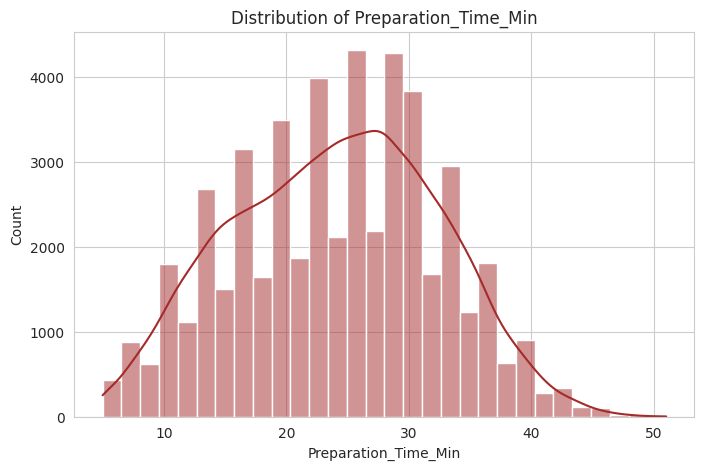

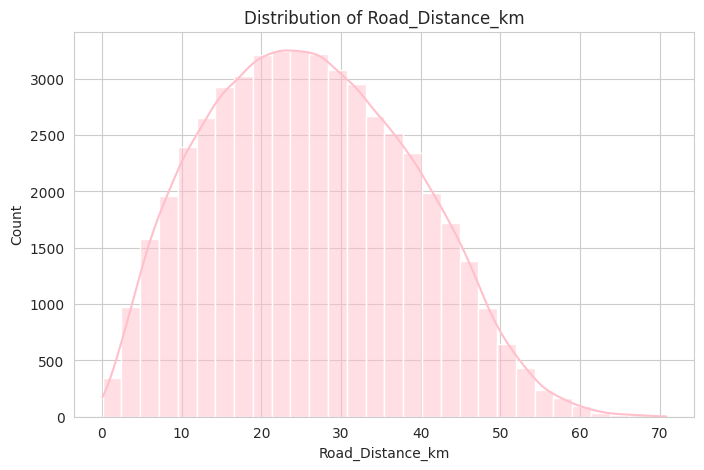

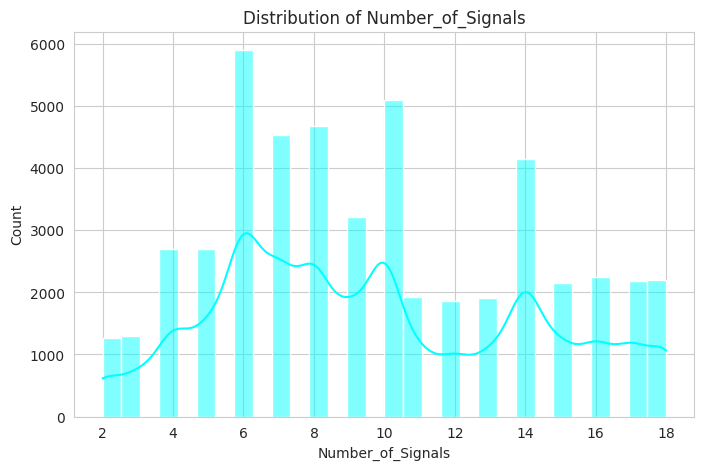

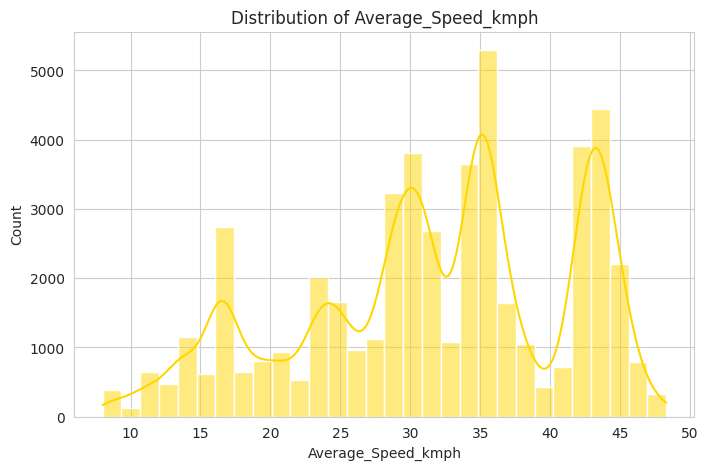

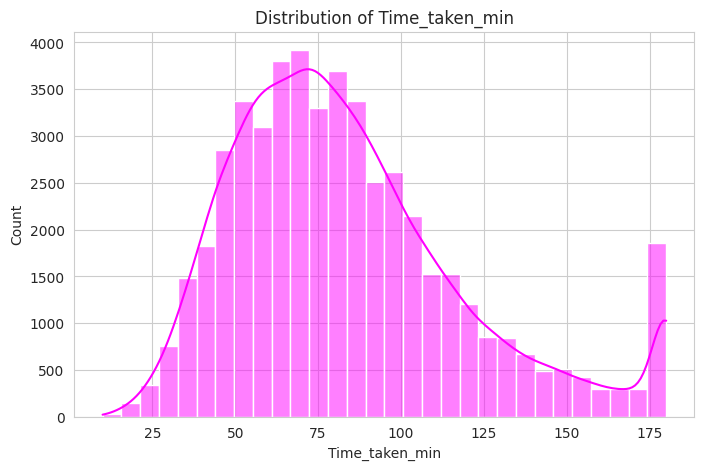

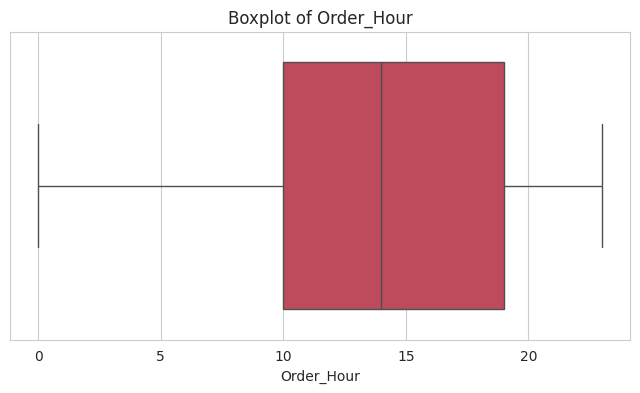

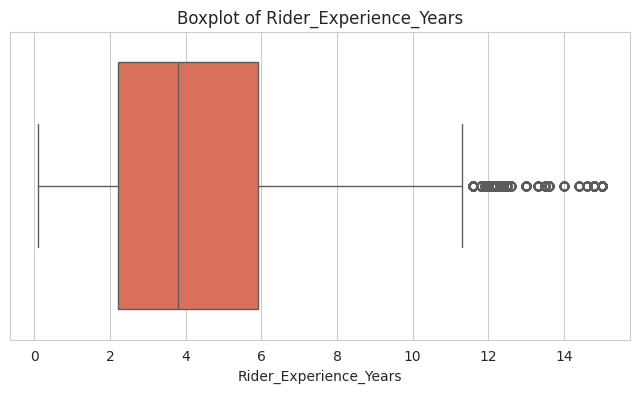

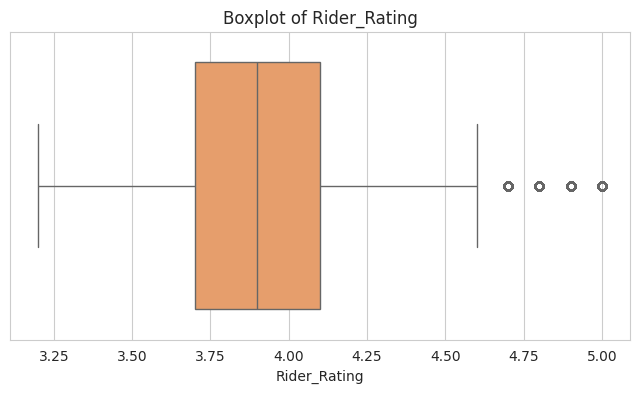

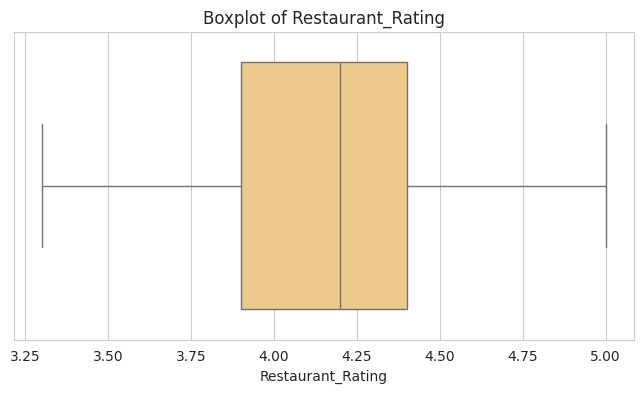

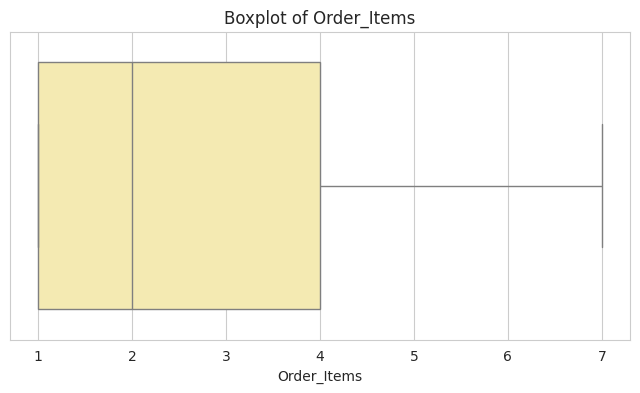

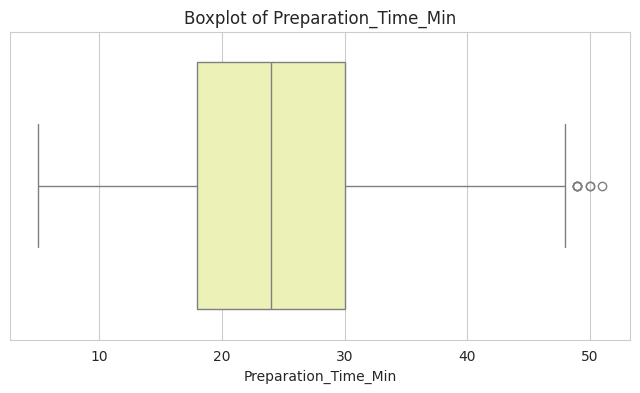

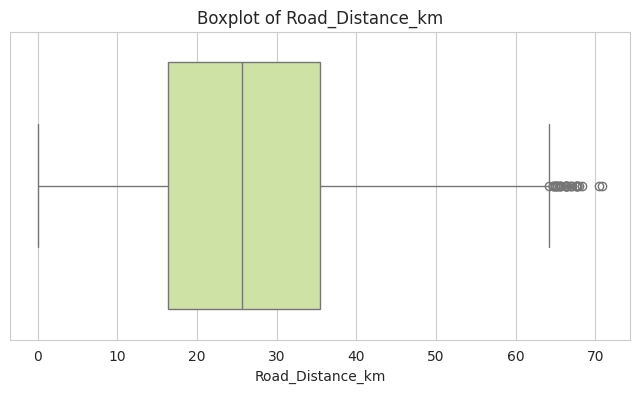

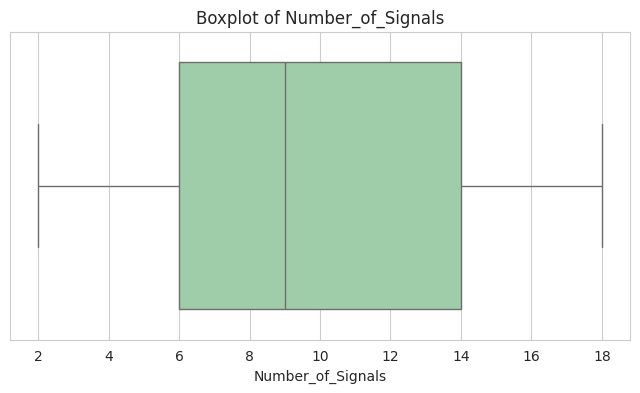

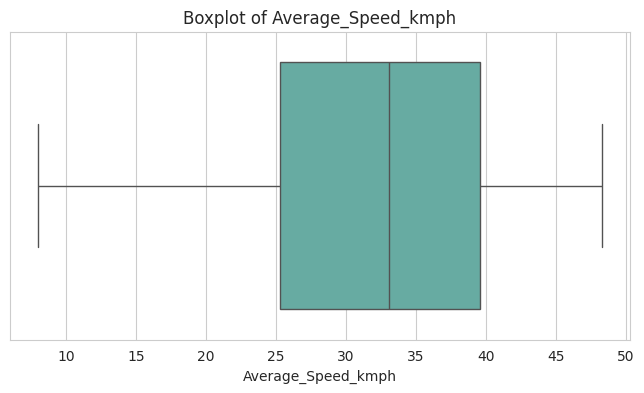

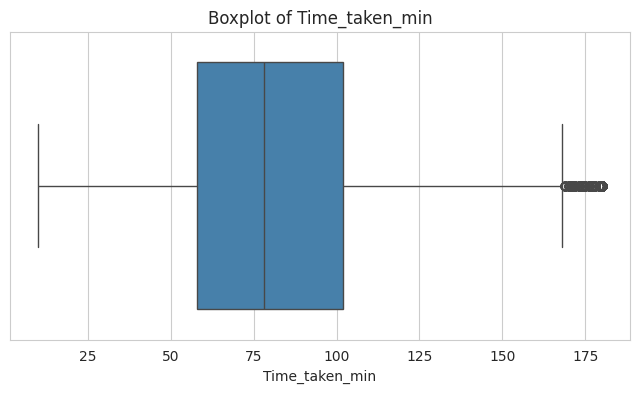

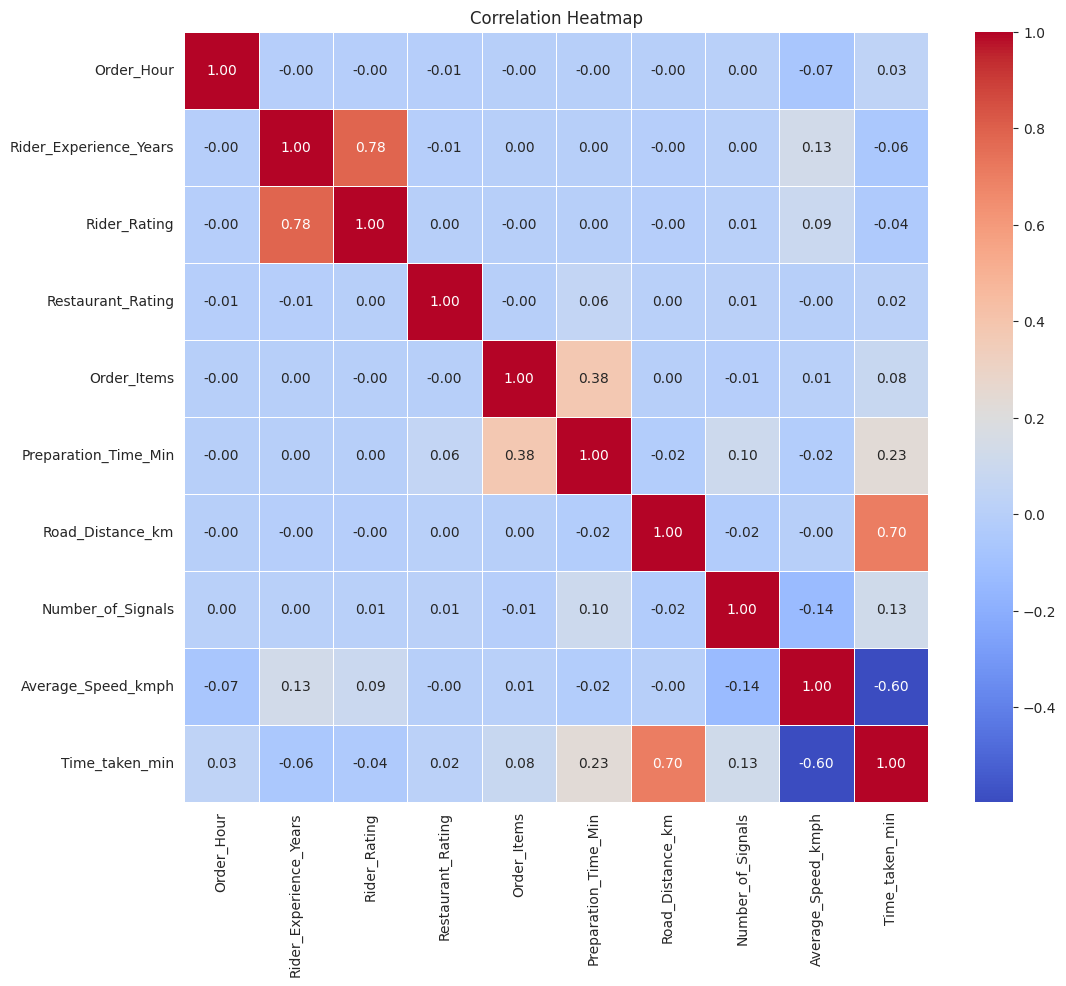

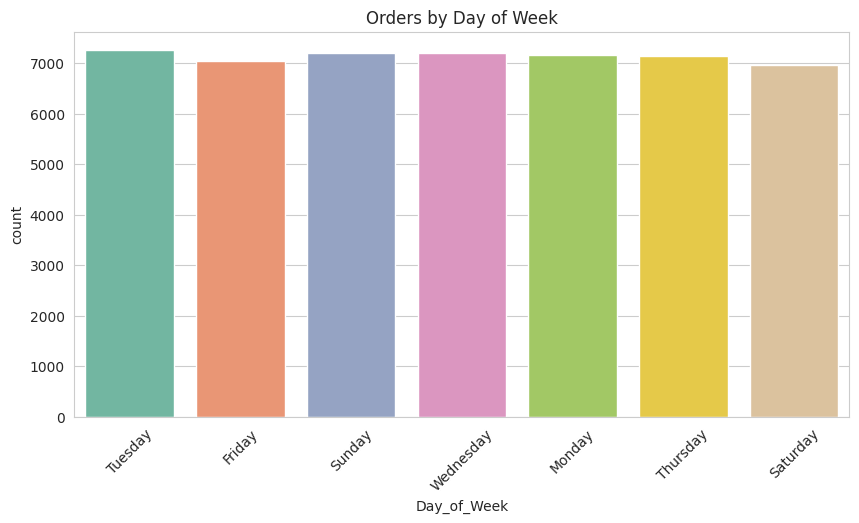

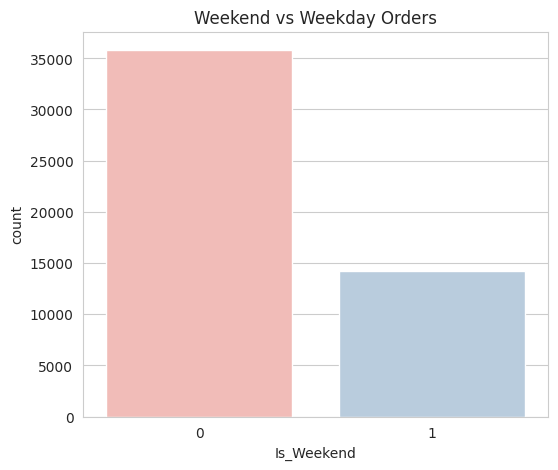

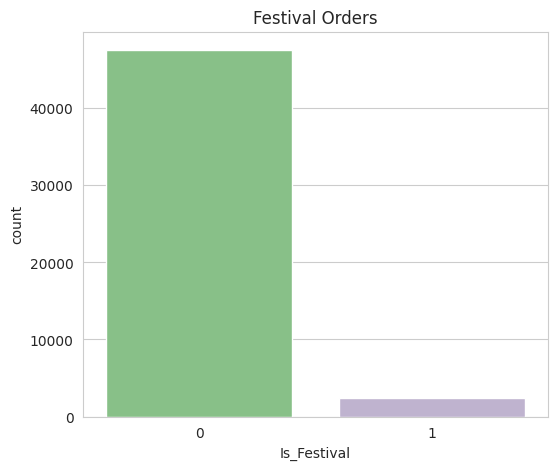

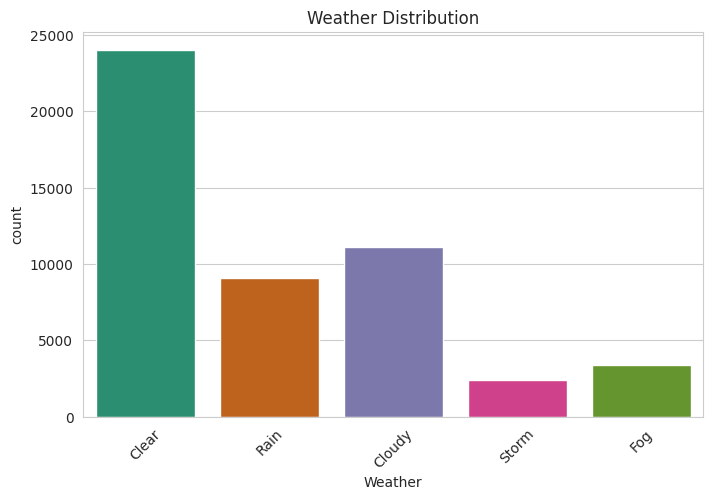

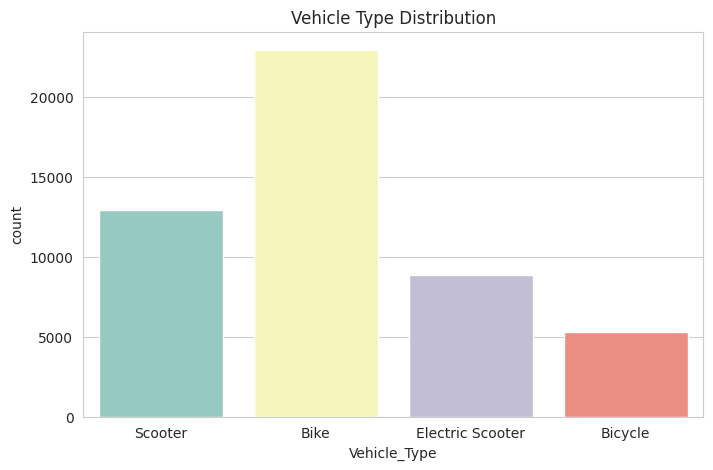

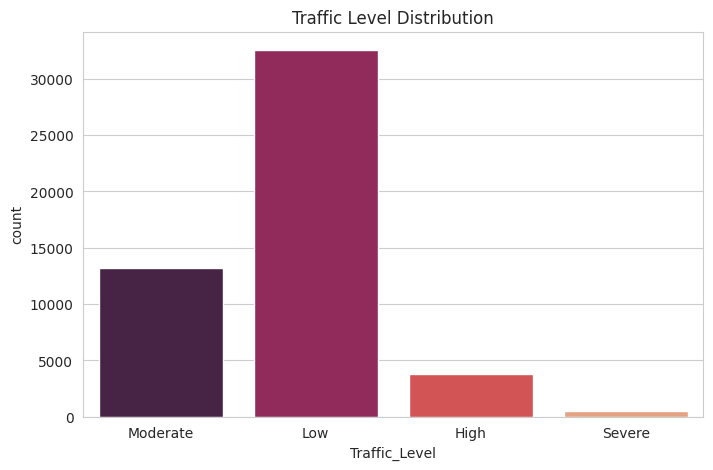

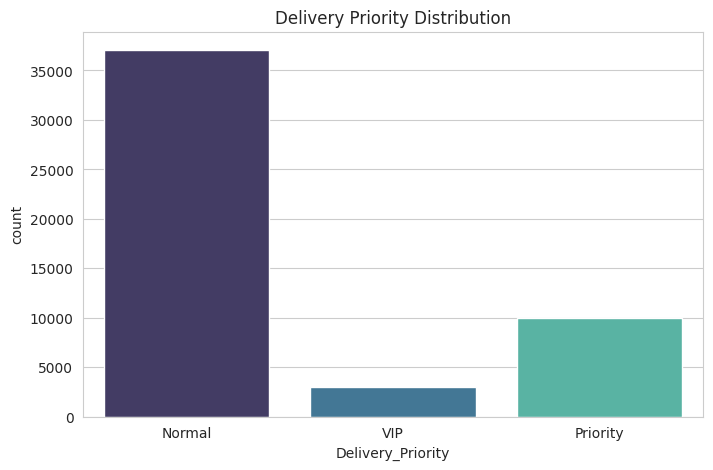

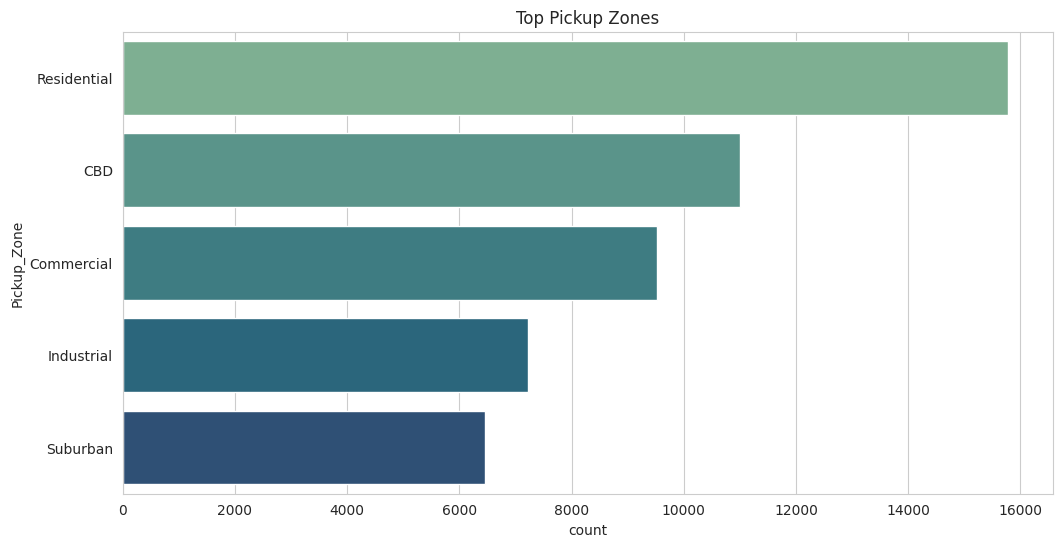

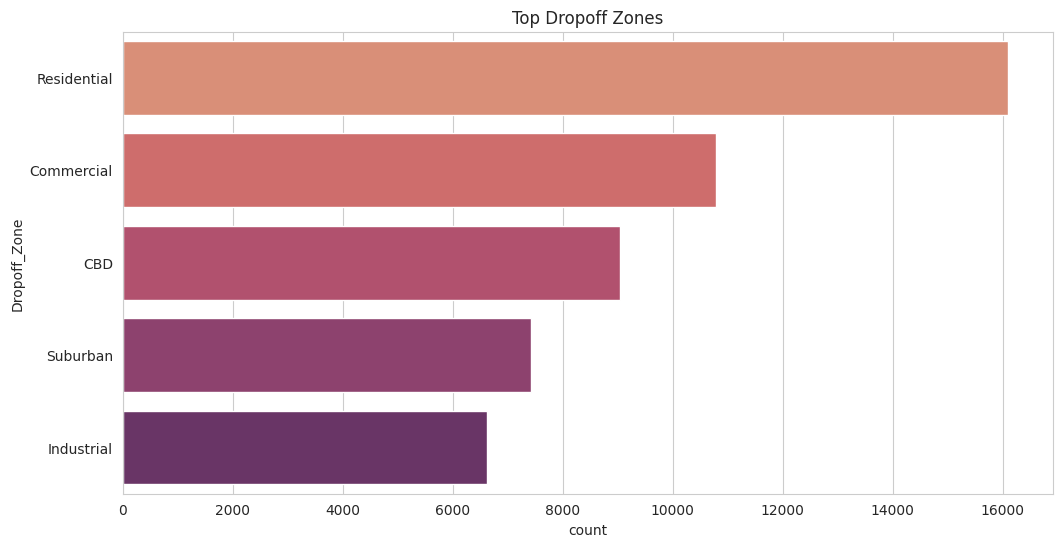

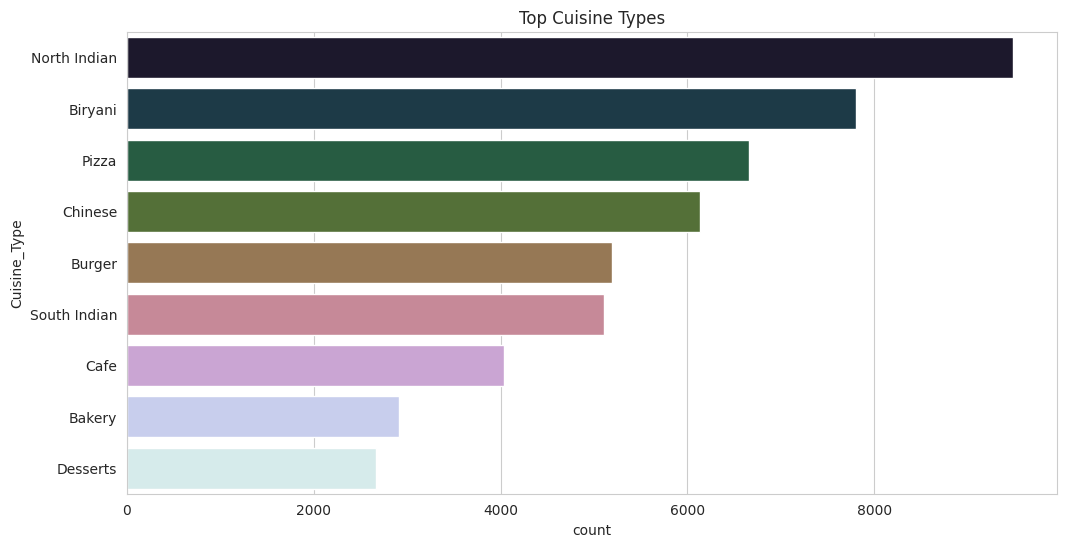

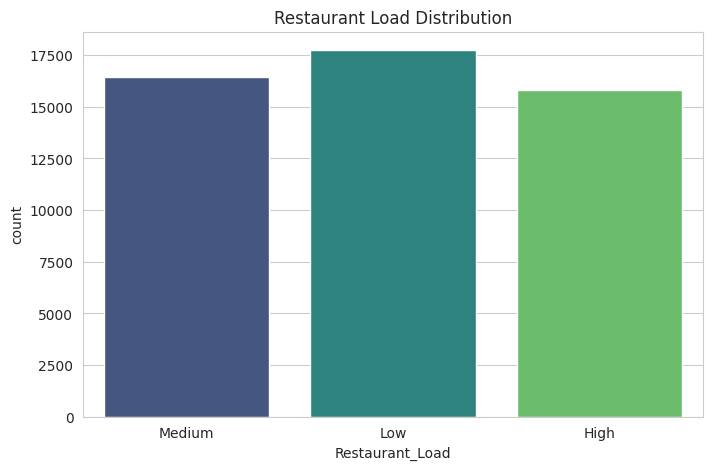

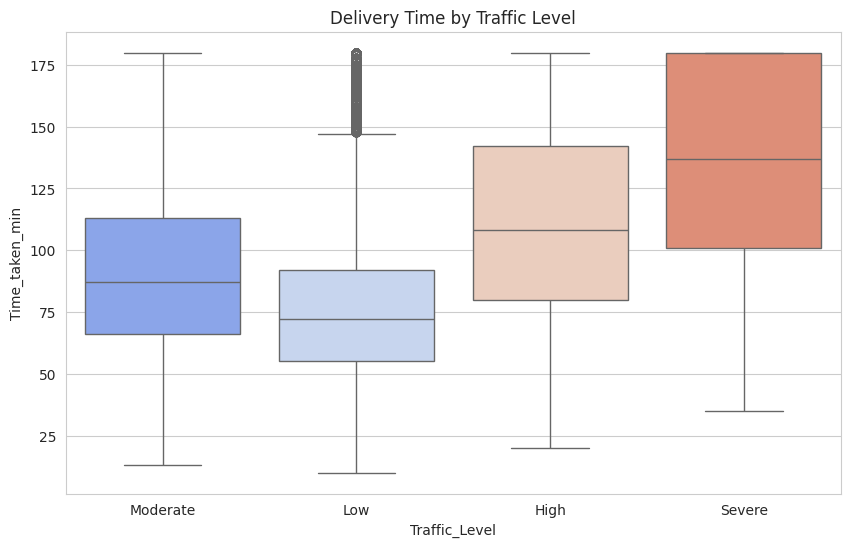

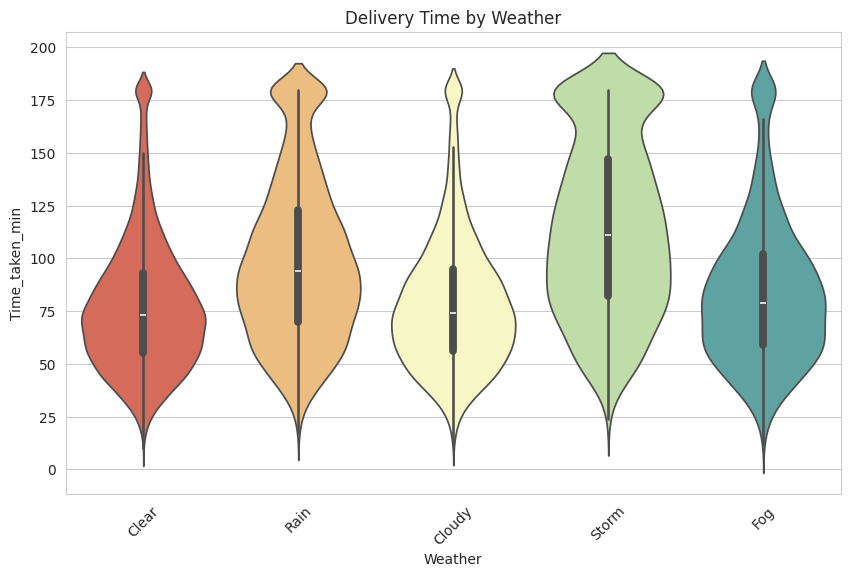

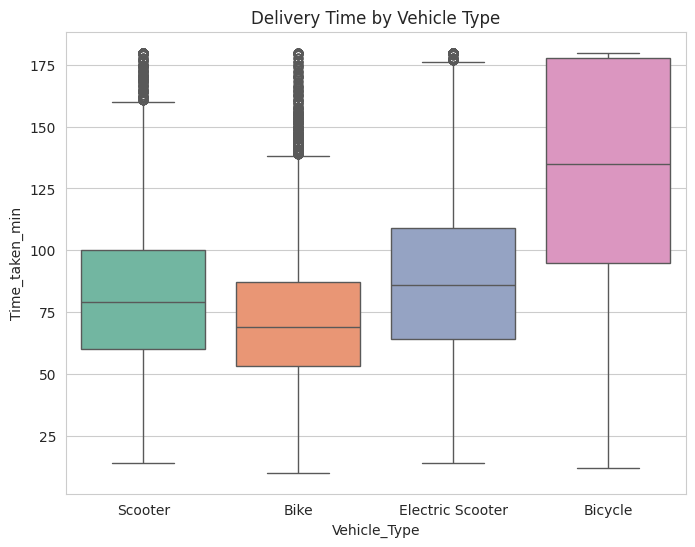

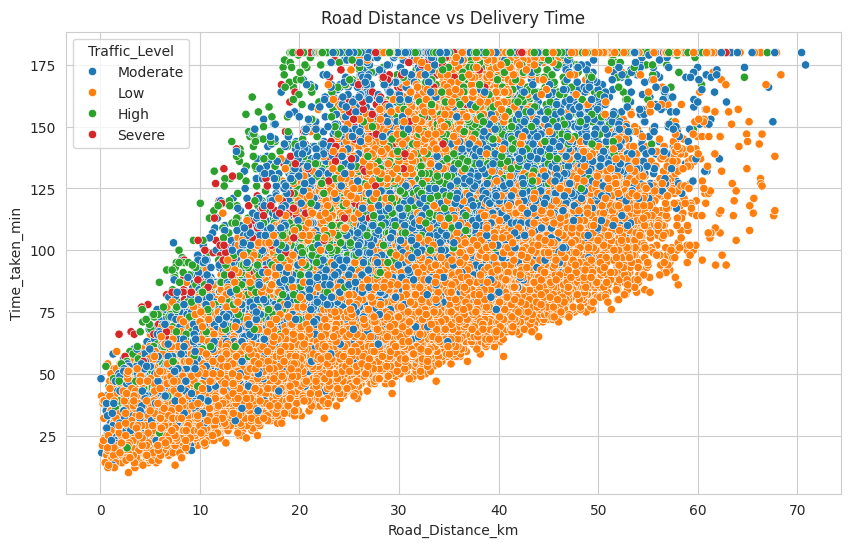

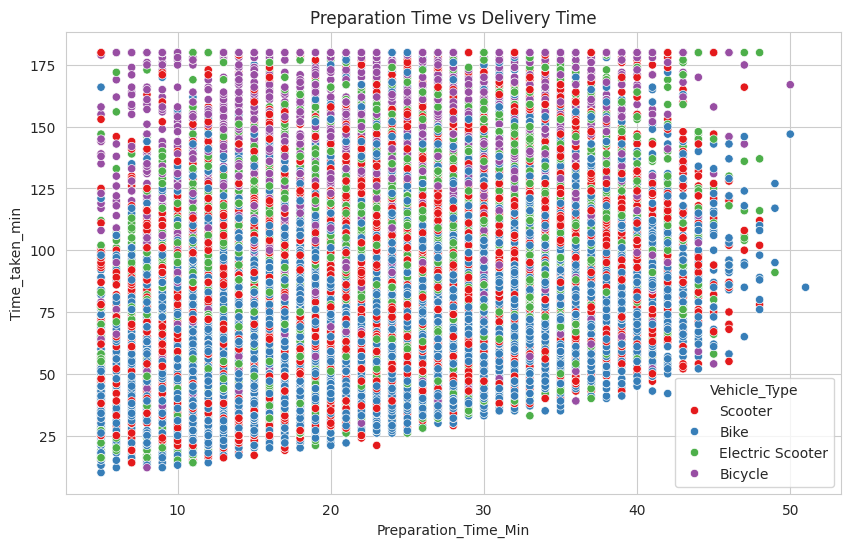

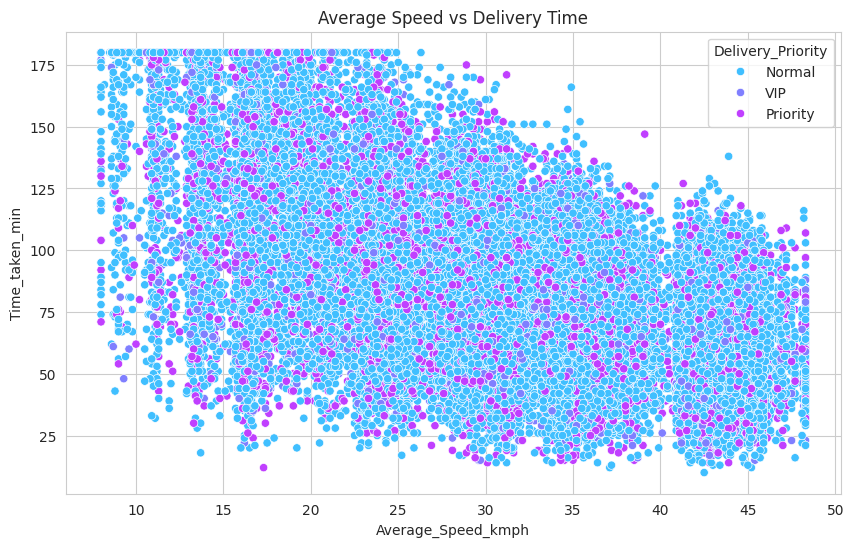

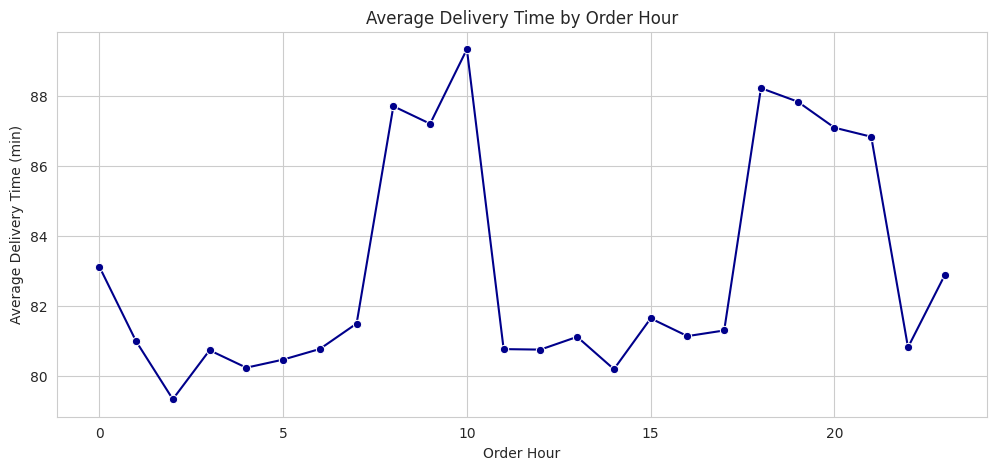

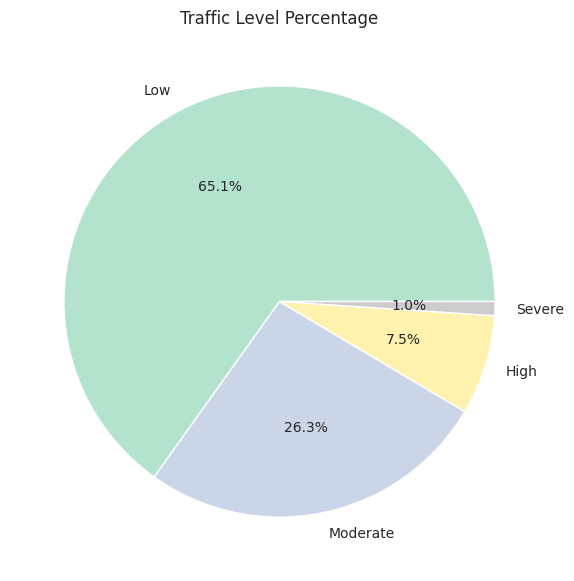

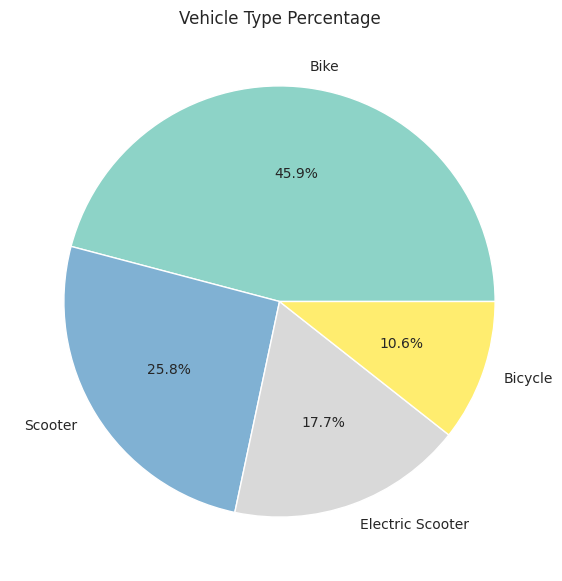

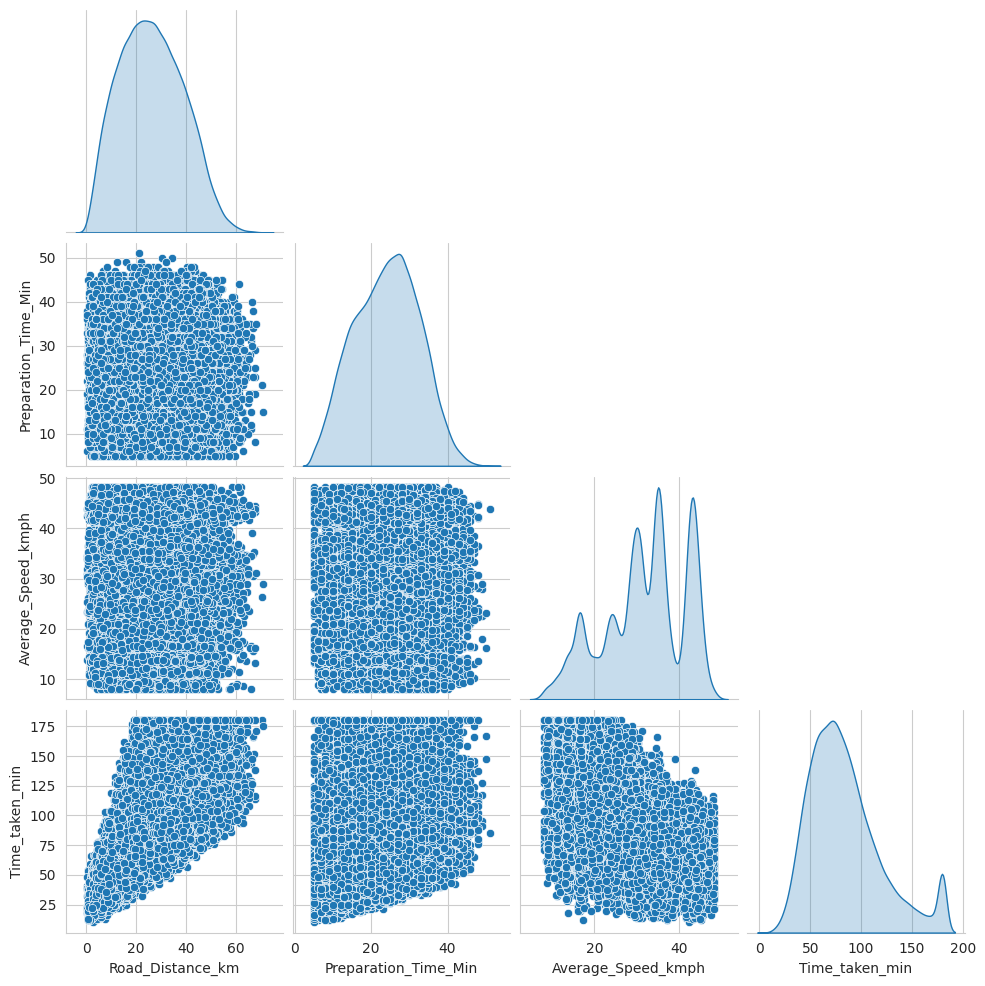

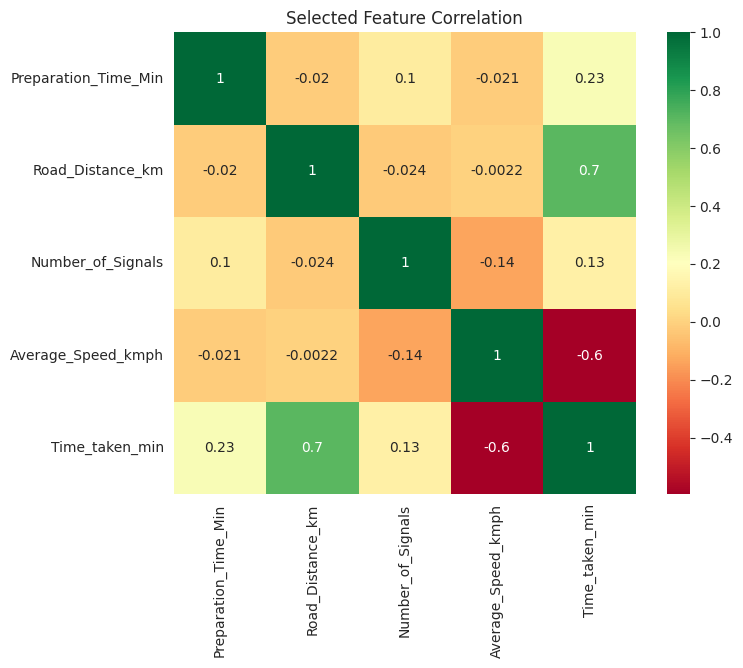

In [12]:

# ==========================================================
# FOOD DELIVERY DATASET - COLORFUL VISUALIZATIONS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# STYLE
# ==========================================================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ==========================================================
# COPY DATA
# ==========================================================

data = df.copy()

# ==========================================================
# DATE CONVERSION
# ==========================================================

data["Order_Date"] = pd.to_datetime(
    data["Order_Date"],
    errors="coerce"
)

# ==========================================================
# NUMERIC & CATEGORICAL COLUMNS
# ==========================================================

num_cols = [
    "Order_Hour",
    "Rider_Experience_Years",
    "Rider_Rating",
    "Restaurant_Rating",
    "Order_Items",
    "Preparation_Time_Min",
    "Road_Distance_km",
    "Number_of_Signals",
    "Average_Speed_kmph",
    "Time_taken_min"
]

cat_cols = [
    "Day_of_Week",
    "Is_Weekend",
    "Is_Festival",
    "Weather",
    "Pickup_Zone",
    "Dropoff_Zone",
    "Vehicle_Type",
    "Cuisine_Type",
    "Restaurant_Load",
    "Delivery_Distance_Category",
    "Traffic_Level",
    "Delivery_Priority"
]

# ==========================================================
# DATA OVERVIEW
# ==========================================================

print(data.info())
print(data.describe())

# ==========================================================
# MISSING VALUE HEATMAP
# ==========================================================

plt.figure(figsize=(14, 5))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

# ==========================================================
# HISTOGRAMS OF NUMERIC FEATURES
# ==========================================================

data[num_cols].hist(
    bins=25,
    figsize=(18, 14),
    color="skyblue",
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18
)

plt.show()

# ==========================================================
# INDIVIDUAL COLORFUL DISTRIBUTIONS
# ==========================================================

colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "cyan", "gold", "magenta"
]

for col, color in zip(num_cols, colors):

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data[col],
        kde=True,
        bins=30,
        color=color
    )

    plt.title(f"Distribution of {col}")

    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

palette = sns.color_palette("Spectral", len(num_cols))

for col, color in zip(num_cols, palette):

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=data[col],
        color=color
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    data[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# ORDERS BY DAY OF WEEK
# ==========================================================

plt.figure(figsize=(10, 5))

sns.countplot(
    data=data,
    x="Day_of_Week",
    palette="Set2"
)

plt.title("Orders by Day of Week")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# WEEKEND VS WEEKDAY
# ==========================================================

plt.figure(figsize=(6, 5))

sns.countplot(
    data=data,
    x="Is_Weekend",
    palette="Pastel1"
)

plt.title("Weekend vs Weekday Orders")

plt.show()

# ==========================================================
# FESTIVAL ORDERS
# ==========================================================

plt.figure(figsize=(6, 5))

sns.countplot(
    data=data,
    x="Is_Festival",
    palette="Accent"
)

plt.title("Festival Orders")

plt.show()

# ==========================================================
# WEATHER DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Weather",
    palette="Dark2"
)

plt.title("Weather Distribution")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# VEHICLE TYPE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Vehicle_Type",
    palette="Set3"
)

plt.title("Vehicle Type Distribution")

plt.show()

# ==========================================================
# TRAFFIC LEVEL DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Traffic_Level",
    palette="rocket"
)

plt.title("Traffic Level Distribution")

plt.show()

# ==========================================================
# DELIVERY PRIORITY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Delivery_Priority",
    palette="mako"
)

plt.title("Delivery Priority Distribution")

plt.show()

# ==========================================================
# TOP PICKUP ZONES
# ==========================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data,
    y="Pickup_Zone",
    order=data["Pickup_Zone"].value_counts().head(10).index,
    palette="crest"
)

plt.title("Top Pickup Zones")

plt.show()

# ==========================================================
# TOP DROPOFF ZONES
# ==========================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data,
    y="Dropoff_Zone",
    order=data["Dropoff_Zone"].value_counts().head(10).index,
    palette="flare"
)

plt.title("Top Dropoff Zones")

plt.show()

# ==========================================================
# CUISINE TYPE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=data,
    y="Cuisine_Type",
    order=data["Cuisine_Type"].value_counts().head(10).index,
    palette="cubehelix"
)

plt.title("Top Cuisine Types")

plt.show()

# ==========================================================
# RESTAURANT LOAD DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Restaurant_Load",
    palette="viridis"
)

plt.title("Restaurant Load Distribution")

plt.show()

# ==========================================================
# DELIVERY TIME BY TRAFFIC LEVEL
# ==========================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="Traffic_Level",
    y="Time_taken_min",
    palette="coolwarm"
)

plt.title("Delivery Time by Traffic Level")

plt.show()

# ==========================================================
# DELIVERY TIME BY WEATHER
# ==========================================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="Weather",
    y="Time_taken_min",
    palette="Spectral"
)

plt.title("Delivery Time by Weather")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# DELIVERY TIME BY VEHICLE TYPE
# ==========================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Vehicle_Type",
    y="Time_taken_min",
    palette="Set2"
)

plt.title("Delivery Time by Vehicle Type")

plt.show()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Road_Distance_km",
    y="Time_taken_min",
    hue="Traffic_Level",
    palette="tab10"
)

plt.title("Road Distance vs Delivery Time")

plt.show()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Preparation_Time_Min",
    y="Time_taken_min",
    hue="Vehicle_Type",
    palette="Set1"
)

plt.title("Preparation Time vs Delivery Time")

plt.show()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Average_Speed_kmph",
    y="Time_taken_min",
    hue="Delivery_Priority",
    palette="cool"
)

plt.title("Average Speed vs Delivery Time")

plt.show()

# ==========================================================
# ORDER HOUR ANALYSIS
# ==========================================================

hour_avg = (
    data.groupby("Order_Hour")["Time_taken_min"]
    .mean()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hour_avg.index,
    y=hour_avg.values,
    marker="o",
    color="darkblue"
)

plt.title("Average Delivery Time by Order Hour")

plt.xlabel("Order Hour")

plt.ylabel("Average Delivery Time (min)")

plt.grid(True)

plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

plt.figure(figsize=(7, 7))

data["Traffic_Level"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Pastel2"
)

plt.ylabel("")

plt.title("Traffic Level Percentage")

plt.show()

plt.figure(figsize=(7, 7))

data["Vehicle_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3"
)

plt.ylabel("")

plt.title("Vehicle Type Percentage")

plt.show()

# ==========================================================
# PAIRPLOT OF IMPORTANT FEATURES
# ==========================================================

sns.pairplot(
    data[[
        "Road_Distance_km",
        "Preparation_Time_Min",
        "Average_Speed_kmph",
        "Time_taken_min"
    ]],
    diag_kind="kde",
    corner=True
)

plt.show()

# ==========================================================
# FINAL SELECTED FEATURE HEATMAP
# ==========================================================

selected = [
    "Preparation_Time_Min",
    "Road_Distance_km",
    "Number_of_Signals",
    "Average_Speed_kmph",
    "Time_taken_min"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    data[selected].corr(),
    annot=True,
    cmap="RdYlGn",
    square=True
)

plt.title("Selected Feature Correlation")

plt.show()

